# Spectral density as a function of $U_{IB}$ #

In [1]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import matplotlib
import h5py
import numpy as np
import class_utils as class_utils
from class_grid import Grid
from class_params import Params
from class_groundstate import groundstate
from class_excitations import excitations
from class_vertices import vertices
from class_perturbation import perturbative
from class_self_energy import Self_Energy
from class_io import IO
from class_plotting import plot2D, plot_cns, plot_omega0
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker


### For different $U_{IB}$ values

In [2]:
config_path = "config.yml" 

dJU = 0.2 # which hopping value are we fixing to
muU = np.sqrt(2) - 1 # which chemical potential we are fixing to

output_dir = class_utils.create_output_dir()
config = class_utils.read_config(config_path)

Lx = config["grid"]["Lx"]
Ly = config["grid"]["Ly"]
cutoff = config["physics"]["cutoff"]
N = config["physics"]["N"]
M = Lx * Ly

grid = Grid(Lx, Ly)

num_en = 150 #150 # 100
num_UIB = 50 # 100
en_vector = np.linspace(-1,2,num_en)
UIBs = np.linspace(-1, 1, num_UIB)

In [3]:
# run this block if you are making the data for the first time

input("confirm that you would like to make the data for the first time")

omega0s = np.zeros(len(UIBs))
omega1s = np.zeros(len(UIBs))
omega2s = np.zeros(len(UIBs))

SE = np.zeros((7, len(en_vector)), dtype=np.complex128)  #7 rows for each contribution, num_en columns ##V: why 7?


#V:  Add poles to this plot!!!
T11 = np.zeros((len(UIBs), len(en_vector)), dtype=np.complex128)
T12 = np.zeros((len(UIBs), len(en_vector)), dtype=np.complex128)
T21 = np.zeros((len(UIBs), len(en_vector)), dtype=np.complex128)
T22 = np.zeros((len(UIBs), len(en_vector)), dtype=np.complex128)
T22_F = np.zeros((len(UIBs), len(en_vector)), dtype=np.complex128)
SE_SI = np.zeros((len(UIBs), len(en_vector)), dtype=np.complex128)

for count, UIB in enumerate(UIBs):
    params = Params(N, dJU, muU, UIB, cutoff)
    print(count,UIB)
    gs = groundstate(params)
    cns = gs.cns()
    n0 = gs.n0(cns)
    psi0 = gs.psi0(cns)
    exc = excitations(grid, params, gs, cns)
    uks, vks, omegaklambda = exc.calculate_matrices()
    verts = vertices(grid, gs, uks, vks, cns, n0)
    pert = perturbative(grid, params, verts, omegaklambda)
    Pert_Energy = pert.perturbative_energy(n0)
    omega0s[count] = Pert_Energy[0]
    omega1s[count] = Pert_Energy[1]
    omega2s[count] = Pert_Energy[2]

    for epol_ind in range(len(en_vector)):
        Epol = en_vector[epol_ind]
        self_energy = Self_Energy(Epol, grid, params, verts, omegaklambda)
        output = self_energy.calculate_self_energy()
        #output = self_energy.calculate_self_energy_perturbative() # perturbative result
        SE[:, epol_ind] = output
    #The zeroth element is the full self energy minus w, used for finding the zero crossings.
    T11[count, :] = SE[1, :]
    T12[count, :] = SE[2, :]
    T21[count, :] = SE[3, :]
    T22[count, :] = SE[4, :]
    T22_F[count, :] = SE[5, :]
    SE_SI[count, :] = SE[6, :]

0 -1.0


KeyboardInterrupt: 

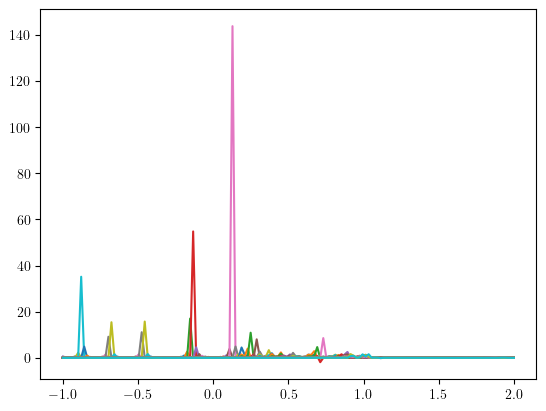

In [ ]:
# construct the spectral function and self energy 
SpectralFuncs = np.zeros((len(UIBs), len(en_vector)), dtype = float)
Sigma = np.zeros((len(UIBs), len(en_vector)),dtype=np.complex128)
Sigma00 = np.zeros((len(UIBs), len(en_vector)),dtype=np.complex128)
#UIB_map = UIBs * np.ones_like(SpectralFuncs)
dOmega = en_vector[1] - en_vector[0]
eta = 0.0001

#
for count in range(0, len(UIBs)):
    en = SE_SI[count]
    en = T11[count] + T12[count] + T21[count]  + T22[count] +  T22_F[count]
    # en =  T12[count]
    SpectralFuncs[count, :] = dOmega * (-2) * np.imag(1./(en_vector - en + 1j * eta))
    Sigma[count, :] = (T11[count] + T12[count] + T21[count]  + T22[count]) +  T22_F[count]
    Sigma00[count, :] = (T11[count] + T12[count] + T21[count]  + T22[count]) 
    
fig, ax = plt.subplots()
for i in range(0, len(UIBs)):
    ax.plot(en_vector, SpectralFuncs[i, :], label = UIBs[i])
# ax.set_ylim(-0.1, 0.0002)
    # plt.legend()

In [ ]:
# check for negative values in the spectral density
a = np.shape(SpectralFuncs)
for row in range(a[0]):
    for col in range(a[1]):
        if SpectralFuncs[row,col] < 0:
            print('negative spectral density:  ',row,col, UIBs[row], en_vector[col],SpectralFuncs[row,col])

negative spectral density:   0 101 -1.0 1.0335570469798658 -0.00016664985306737032
negative spectral density:   0 108 -1.0 1.174496644295302 -0.0028294028263297303
negative spectral density:   0 111 -1.0 1.2348993288590604 -0.0005357107402374831
negative spectral density:   0 126 -1.0 1.536912751677852 -0.00015729359120886705
negative spectral density:   0 128 -1.0 1.577181208053691 -4.130067133292674e-05
negative spectral density:   0 131 -1.0 1.6375838926174495 -0.000466014973743983
negative spectral density:   0 134 -1.0 1.697986577181208 -0.0005714545919944765
negative spectral density:   0 135 -1.0 1.7181208053691273 -5.734592474596527e-06
negative spectral density:   0 136 -1.0 1.7382550335570466 -7.824270343900117e-06
negative spectral density:   0 137 -1.0 1.7583892617449663 -6.323263631462208e-05
negative spectral density:   0 138 -1.0 1.7785234899328857 -1.6016490202695636e-06
negative spectral density:   0 140 -1.0 1.8187919463087248 -9.285553907506822e-06
negative spectral 

<>:54: SyntaxWarning: invalid escape sequence '\o'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:58: SyntaxWarning: invalid escape sequence '\m'
<>:54: SyntaxWarning: invalid escape sequence '\o'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:58: SyntaxWarning: invalid escape sequence '\m'
/var/folders/ss/8jmv74q91hx88tdtr0hdx12c0000gn/T/ipykernel_29709/1804717549.py:54: SyntaxWarning: invalid escape sequence '\o'
  cb1.set_label(label="$A(0,\omega)$",size=15,weight='bold')
/var/folders/ss/8jmv74q91hx88tdtr0hdx12c0000gn/T/ipykernel_29709/1804717549.py:56: SyntaxWarning: invalid escape sequence '\m'
  cb2.set_label(label = "$-2\mathrm{Im\Sigma(0,\omega)}$",size=15,weight='bold')
/var/folders/ss/8jmv74q91hx88tdtr0hdx12c0000gn/T/ipykernel_29709/1804717549.py:58: SyntaxWarning: invalid escape sequence '\m'
  cb3.set_label(label = "$-2\mathrm{Im\Sigma^{(0,0)}(0,\omega)}$",size=15,weight='bold')


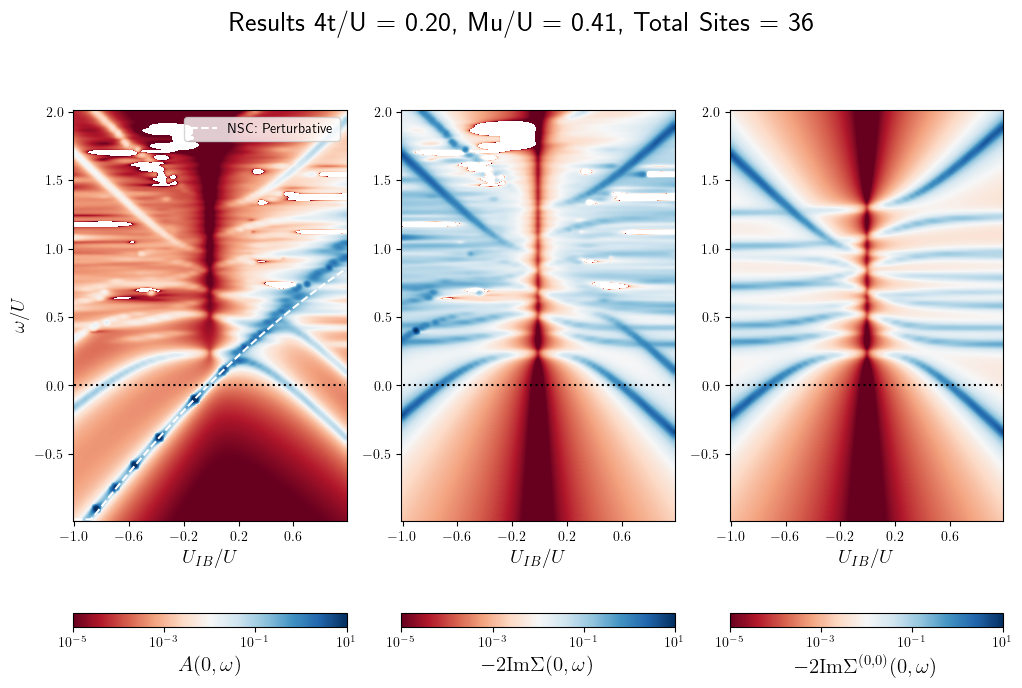

In [ ]:

plt.rcParams['text.usetex'] = True

# Rotate the image by -90 degrees
SpectralFuncs_rot = np.rot90(SpectralFuncs, 1)
Sigma_rot = np.rot90(Sigma, 1)
Sigma00_rot = np.rot90(Sigma00, 1)


fig, (ax1, ax2, ax3) = plt.subplots(ncols = 3, figsize = (12,8))

# Create the plot
# Set the aspect ratio to the ratio of the number of x points to the number of y points
aspect_ratio = 1
im1 = ax1.imshow(SpectralFuncs_rot, interpolation = 'bicubic', cmap='RdBu', 
aspect = aspect_ratio, norm=matplotlib.colors.LogNorm())
im2 = ax2.imshow(-2*np.imag(Sigma_rot), interpolation = 'bicubic',cmap='RdBu', aspect = aspect_ratio, norm=matplotlib.colors.LogNorm())
im3 = ax3.imshow(-2*np.imag(Sigma00_rot), interpolation = 'bicubic',cmap='RdBu', aspect = aspect_ratio,norm=matplotlib.colors.LogNorm())




# Select a subset of dJUs and en_vector for the ticks
num_xticks = 6
num_yticks = 7

xticks = np.linspace(0, SpectralFuncs_rot.shape[1], num_xticks, endpoint=True, dtype=int)
yticks = np.linspace(0, SpectralFuncs_rot.shape[0], num_yticks, endpoint=True, dtype=int)

xticklabels = np.round(np.linspace(min(UIBs), max(UIBs), num_xticks),2)
yticklabels = np.round(np.linspace(max(en_vector), min(en_vector), num_yticks), 2)

# Format the labels in LaTeX
xticklabels = [r'$\mathrm{{{}}}$'.format(label) for label in xticklabels]
yticklabels = [r'$\mathrm{{{}}}$'.format(label) for label in yticklabels]

ax1.set_xticks(xticks)
ax1.set_yticks(yticks)
ax2.set_xticks(xticks)
ax2.set_yticks(yticks)
ax3.set_xticks(xticks)
ax3.set_yticks(yticks)
ax1.set_xticklabels(xticklabels)
ax1.set_yticklabels(yticklabels)
ax2.set_xticklabels(xticklabels)
ax2.set_yticklabels(yticklabels)
ax3.set_xticklabels(xticklabels)
ax3.set_yticklabels(yticklabels)
ax1.set_xlabel(r'$U_{IB}/U$', fontsize=14)
ax2.set_xlabel(r'$U_{IB}/U$', fontsize=14)
ax3.set_xlabel(r'$U_{IB}/U$', fontsize=14)
ax1.set_ylabel(r'$\omega/U$', fontsize=14)

cb1 = plt.colorbar(im1,orientation="horizontal")
cb1.set_label(label="$A(0,\omega)$",size=15,weight='bold')
cb2 = plt.colorbar(im2,orientation="horizontal")
cb2.set_label(label = "$-2\mathrm{Im\Sigma(0,\omega)}$",size=15,weight='bold')
cb3 = plt.colorbar(im3,orientation="horizontal")
cb3.set_label(label = "$-2\mathrm{Im\Sigma^{(0,0)}(0,\omega)}$",size=15,weight='bold')
im1.set_clim(1e-5, 1e1)
im2.set_clim(1e-5, 1e1)
im3.set_clim(1e-5, 1e1)


idx = np.searchsorted(en_vector, 0, side="left") # find \omega = 0

#X, Y = np.meshgrid(UIBs, omega0s + omega1s + omega2s)
# ax2 = ax.twinx()
# Transform the y-coordinates of the plot to match the image coordinates
plot_x = np.interp(UIBs, (UIBs.min(), UIBs.max()), (0, SpectralFuncs_rot.shape[1]-1))
plot_y = SpectralFuncs_rot.shape[0] - 1 - np.interp(omega0s + omega1s + omega2s, (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))
plot_non_T = SpectralFuncs_rot.shape[0] - 1 - np.interp(np.real(Sigma_rot[idx,:]), (en_vector.min(), en_vector.max()), (0, SpectralFuncs_rot.shape[0]-1))
plot_0 = len(en_vector) - idx + np.zeros(len(plot_y))

# Overlay the plot on top of the imshow figure
fig.suptitle(f"Results 4t/U = {dJU:0.2f}, Mu/U = {muU:0.2f}, Total Sites = {M}", fontsize = 20)
ax1.plot(plot_x, plot_y, linestyle = '--', label='NSC:  Perturbative', color='white', linewidth=1.5)
#ax1.plot(plot_x, plot_non_T, linestyle = ':', label='NSC:  Ladder', color='white', linewidth=1.5)
ax1.plot(plot_x, plot_0, linestyle = ':', color='black', linewidth=1.5)
ax2.plot(plot_x, plot_0, linestyle = ':', color='black', linewidth=1.5)
ax3.plot(plot_x, plot_0, linestyle = ':', color='black', linewidth=1.5)
#ax2.plot(plot_x, plot_y, linestyle = '--', label='Perturbative - Rayl. Schr.', color='white', linewidth=1.5)

ax1.legend()

plt.show()

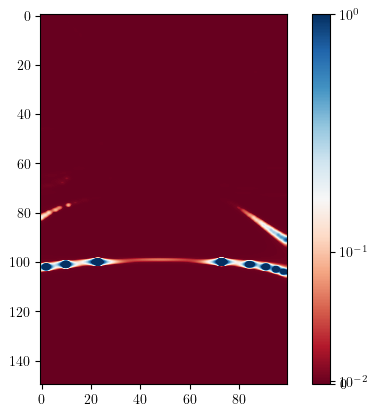

In [ ]:
plt.imshow(SpectralFuncs_rot, interpolation = 'bicubic', cmap='RdBu',aspect = aspect_ratio, vmin=0, vmax=1)
#logscale but with negative values

plt.imshow(SpectralFuncs_rot, interpolation = 'bicubic', cmap='RdBu',aspect = aspect_ratio, norm=matplotlib.colors.SymLogNorm(linthresh=0.03, linscale=0.03, vmin=0, vmax=1))
# plt.imshow(SpectralFuncs_rot, interpolation = 'bicubic', cmap='RdBu',aspect = aspect_ratio, norm=matplotlib.colors.LogNorm())
plt.colorbar()